# Финальный проект: прогноз полезного сигнала

Задача: по первым `N = 4000` noisy-измерениям каждой реализации построить прогноз полезного сигнала на следующие `1000` отсчетов, то есть на `50` секунд при шаге дискретизации `dt = 0.05` с.

Файлы:

- `train.csv` и `test.csv` — измерения с шумом;
- `etalon_for_train.csv` и `etalon_for_test.csv` — истинный полезный сигнал без шума.

Результаты сохраняются в:

- `forecast_test.csv` — прогноз полезного сигнала для тестовой выборки, форма `(500, 1000)`;
- `metrics_by_time.csv` — средняя ошибка и СКП/RMSE по каждому горизонту прогноза;
- `summary_metrics.csv` — агрегированные метрики качества.


### 1. Загрузка данных

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import savgol_filter
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error

DATA_DIR = Path(".")
DT = 0.05
N_HISTORY = 4000
N_FORECAST = 1000

def load_csv(name):
    return np.loadtxt(DATA_DIR / name, delimiter=",", dtype=np.float32)

train = load_csv("train.csv")
test = load_csv("test.csv")
etalon_train = load_csv("etalon_for_train.csv")
etalon_test = load_csv("etalon_for_test.csv")

print("train:", train.shape)
print("test:", test.shape)
print("etalon_train:", etalon_train.shape)
print("etalon_test:", etalon_test.shape)

train: (1000, 5000)
test: (500, 5000)
etalon_train: (1000, 5000)
etalon_test: (500, 5000)


## 2. Формирование обучающей и тестовой постановки

In [2]:
X_train_raw = train[:, :N_HISTORY]
y_train = etalon_train[:, N_HISTORY:N_HISTORY + N_FORECAST]

X_test_raw = test[:, :N_HISTORY]
y_test = etalon_test[:, N_HISTORY:N_HISTORY + N_FORECAST]

time_history = np.arange(N_HISTORY) * DT
time_forecast = np.arange(N_FORECAST) * DT

print("X_train:", X_train_raw.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test_raw.shape)
print("y_test:", y_test.shape)

X_train: (1000, 4000)
y_train: (1000, 1000)
X_test: (500, 4000)
y_test: (500, 1000)


## 3. Визуальный контроль данных

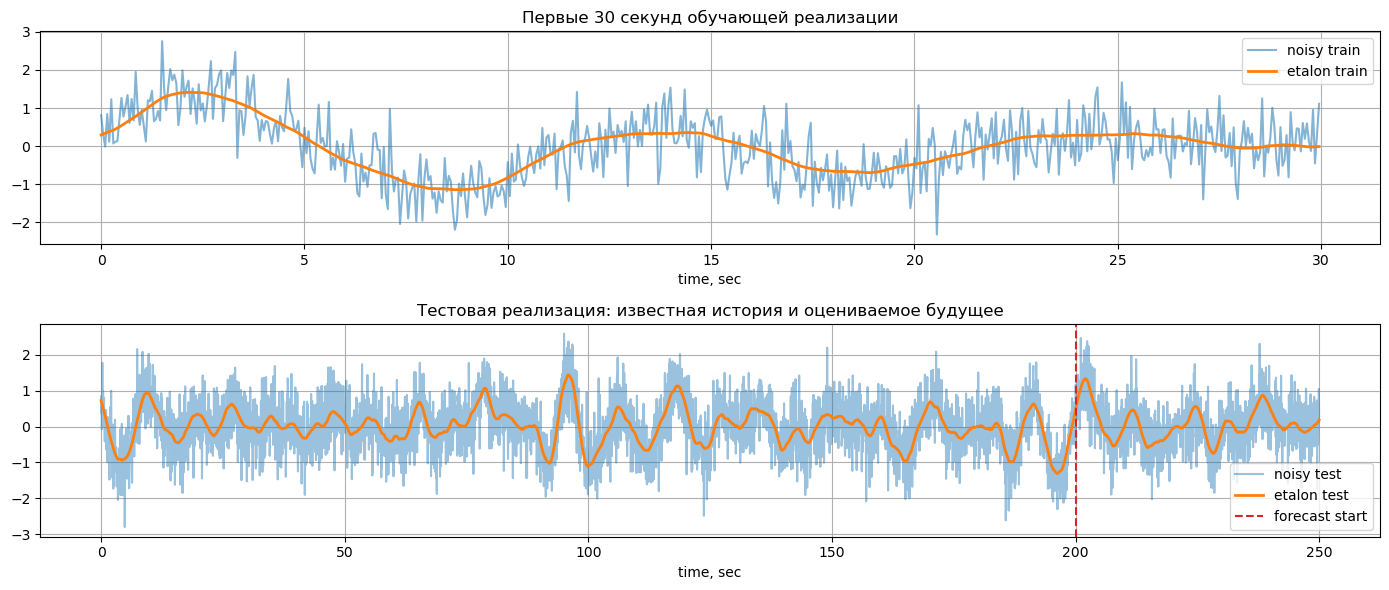

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=False)

idx = 0
axes[0].plot(time_history[:600], train[idx, :600], alpha=0.55, label="noisy train")
axes[0].plot(time_history[:600], etalon_train[idx, :600], linewidth=2, label="etalon train")
axes[0].set_title("Первые 30 секунд обучающей реализации")
axes[0].set_xlabel("time, sec")
axes[0].grid()
axes[0].legend()

axes[1].plot(np.arange(5000) * DT, test[idx], alpha=0.45, label="noisy test")
axes[1].plot(np.arange(5000) * DT, etalon_test[idx], linewidth=2, label="etalon test")
axes[1].axvline(N_HISTORY * DT, color="tab:red", linestyle="--", label="forecast start")
axes[1].set_title("Тестовая реализация: известная история и оцениваемое будущее")
axes[1].set_xlabel("time, sec")
axes[1].grid()
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Сравнение нескольких простых алгоритмов

Проверяются:

1. наивный прогноз последним известным значением;
2. Ridge по последним 100 отсчетам;
3. PCA + Ridge по всей истории;
4. сглаживание известной истории теста + PCA + Ridge.

Дальше используется лучший устойчивый вариант из этой таблицы.


In [4]:
def evaluate_prediction(name, pred):
    return {
        "model": name,
        "mse": mean_squared_error(y_test, pred),
        "rmse": float(np.sqrt(mean_squared_error(y_test, pred))),
        "mae": mean_absolute_error(y_test, pred),
    }

candidate_rows = []

# 1. Naive baseline
pred_last = np.repeat(X_test_raw[:, -1:], N_FORECAST, axis=1)
candidate_rows.append(evaluate_prediction("last observed value", pred_last))

# 2. Ridge on last 100 points
ridge_w100 = make_pipeline(StandardScaler(), Ridge(alpha=10.0))
ridge_w100.fit(X_train_raw[:, -100:], y_train)
pred_w100 = ridge_w100.predict(X_test_raw[:, -100:])
candidate_rows.append(evaluate_prediction("Ridge(last 100)", pred_w100))

# 3. PCA + Ridge on raw history
pca_ridge_raw = make_pipeline(
    StandardScaler(),
    PCA(n_components=50, random_state=42),
    Ridge(alpha=10.0),
)
pca_ridge_raw.fit(X_train_raw, y_train)
pred_pca_raw = pca_ridge_raw.predict(X_test_raw)
candidate_rows.append(evaluate_prediction("PCA(50)+Ridge(raw history)", pred_pca_raw))

# 4. Smoothed test history + tuned PCA/Ridge
X_test_smooth = savgol_filter(X_test_raw, window_length=251, polyorder=3, axis=1).astype(np.float32)
pca_ridge_smooth = make_pipeline(
    StandardScaler(),
    PCA(n_components=80, random_state=42),
    Ridge(alpha=100.0),
)
pca_ridge_smooth.fit(X_train_raw, y_train)
pred_smooth = pca_ridge_smooth.predict(X_test_smooth)
candidate_rows.append(evaluate_prediction("SavGol(test)+PCA(80)+Ridge(100)", pred_smooth))

candidate_results = pd.DataFrame(candidate_rows).sort_values("mse")
candidate_results

,model,mse,rmse,mae
3,SavGol(test)+PCA(80)+Ridge(100),0.257724,0.507665,0.405035
2,PCA(50)+Ridge(raw history),0.264213,0.514016,0.410574
1,Ridge(last 100),0.275813,0.525179,0.416879
0,last observed value,0.841165,0.917151,0.733040


## 5. Финальный алгоритм

Финальный алгоритм:

1. берет первые `4000` noisy-отсчетов тестовой реализации;
2. сглаживает только известную историю фильтром Savitzky-Golay (`window_length=251`, `polyorder=3`);
3. обучает прямую многовыходную модель `StandardScaler -> PCA(80) -> Ridge(alpha=100)` на `train[:, :4000] -> etalon_train[:, 4000:5000]`;
4. прогнозирует сразу весь горизонт из `1000` отсчетов.


In [5]:
final_model = make_pipeline(
    StandardScaler(),
    PCA(n_components=80, random_state=42),
    Ridge(alpha=100.0),
)

X_test_final = savgol_filter(X_test_raw, window_length=251, polyorder=3, axis=1).astype(np.float32)
final_model.fit(X_train_raw, y_train)
forecast = final_model.predict(X_test_final).astype(np.float32)

print("forecast shape:", forecast.shape)

forecast shape: (500, 1000)


## 6. Метрики

In [6]:
error = forecast - y_test
mean_error_by_time = error.mean(axis=0)
rmse_by_time = np.sqrt((error ** 2).mean(axis=0))

metrics_by_time = pd.DataFrame({
    "time_sec": time_forecast,
    "mean_error": mean_error_by_time,
    "rmse": rmse_by_time,
})

summary_metrics = pd.DataFrame([{
    "overall_mse": mean_squared_error(y_test, forecast),
    "overall_rmse": float(np.sqrt(mean_squared_error(y_test, forecast))),
    "overall_mae": mean_absolute_error(y_test, forecast),
    "mean_abs_bias": float(np.mean(np.abs(mean_error_by_time))),
    "max_abs_bias": float(np.max(np.abs(mean_error_by_time))),
    "mean_rmse_by_time": float(np.mean(rmse_by_time)),
    "max_rmse_by_time": float(np.max(rmse_by_time)),
}])

display(summary_metrics)
display(metrics_by_time.head())

,overall_mse,overall_rmse,overall_mae,mean_abs_bias,max_abs_bias,mean_rmse_by_time,max_rmse_by_time
0,0.257724,0.507665,0.405035,0.019663,0.047943,0.506071,0.545385


,time_sec,mean_error,rmse
0,0.00,0.011282,0.236775
1,0.05,0.011611,0.244203
2,0.10,0.012169,0.251679
3,0.15,0.012651,0.259156
4,0.20,0.013194,0.266712


## 7. Графики качества

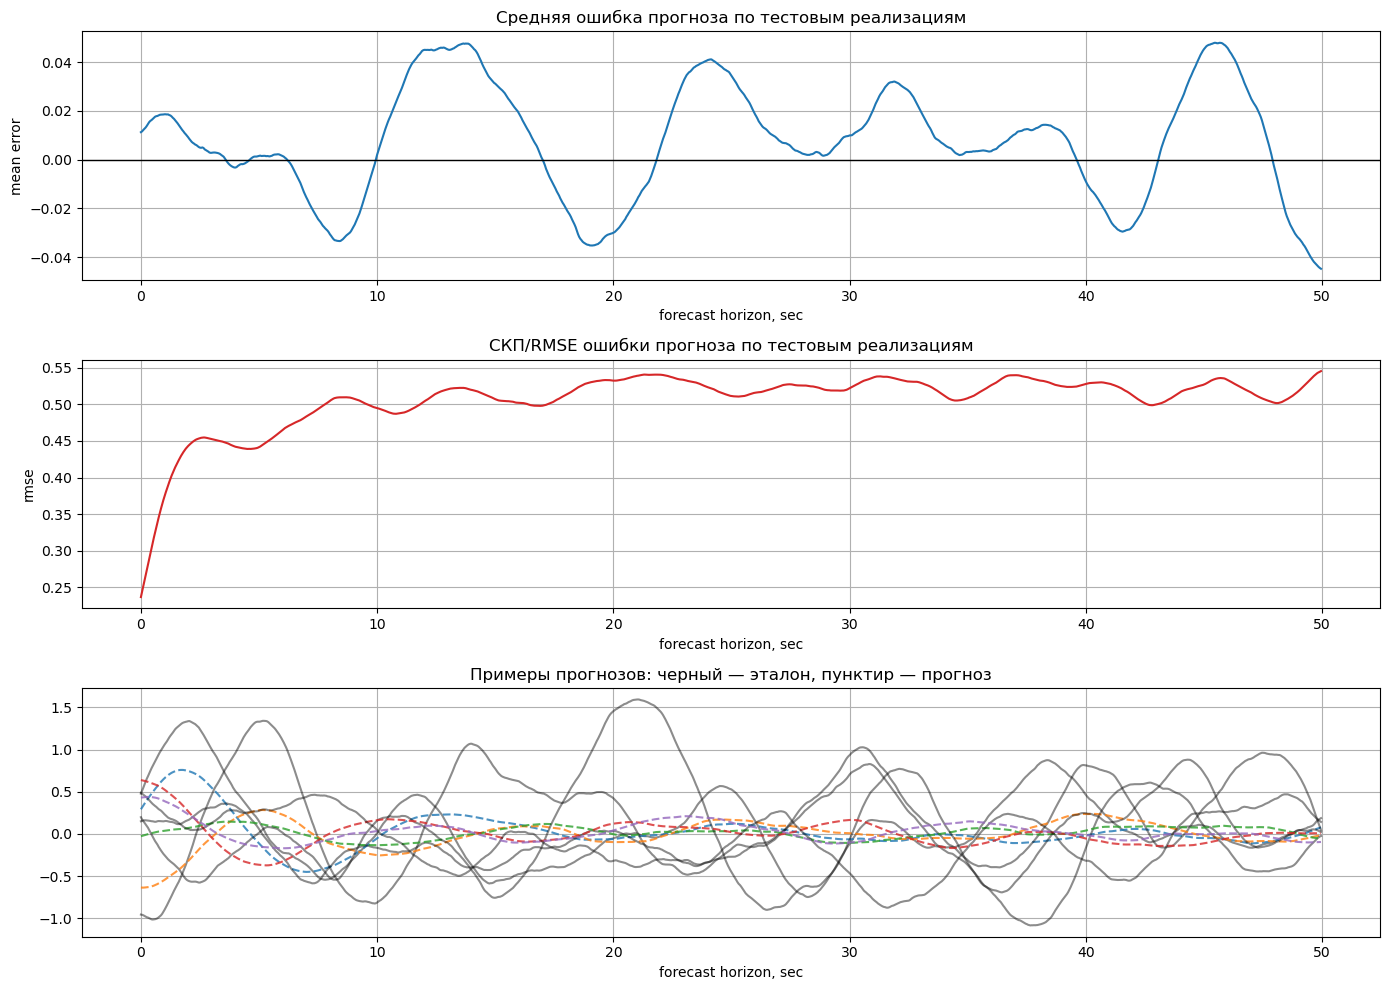

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)

axes[0].plot(time_forecast, mean_error_by_time)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Средняя ошибка прогноза по тестовым реализациям")
axes[0].set_xlabel("forecast horizon, sec")
axes[0].set_ylabel("mean error")
axes[0].grid()

axes[1].plot(time_forecast, rmse_by_time, color="tab:red")
axes[1].set_title("СКП/RMSE ошибки прогноза по тестовым реализациям")
axes[1].set_xlabel("forecast horizon, sec")
axes[1].set_ylabel("rmse")
axes[1].grid()

for i in range(5):
    axes[2].plot(time_forecast, y_test[i], color="black", alpha=0.45)
    axes[2].plot(time_forecast, forecast[i], linestyle="--", alpha=0.8)
axes[2].set_title("Примеры прогнозов: черный — эталон, пунктир — прогноз")
axes[2].set_xlabel("forecast horizon, sec")
axes[2].grid()

plt.tight_layout()
plt.show()

## 8. Сохранение результатов

In [8]:
pd.DataFrame(forecast).to_csv(DATA_DIR / "forecast_test.csv", index=False, header=False)
metrics_by_time.to_csv(DATA_DIR / "metrics_by_time.csv", index=False)
summary_metrics.to_csv(DATA_DIR / "summary_metrics.csv", index=False)
candidate_results.to_csv(DATA_DIR / "candidate_results.csv", index=False)

print("Saved:")
print(DATA_DIR / "forecast_test.csv")
print(DATA_DIR / "metrics_by_time.csv")
print(DATA_DIR / "summary_metrics.csv")
print(DATA_DIR / "candidate_results.csv")

Saved:
forecast_test.csv
metrics_by_time.csv
summary_metrics.csv
candidate_results.csv


## Итоговый вывод

Наиболее устойчивый из проверенных быстрых вариантов — сглаживание известной истории тестового сигнала и прямой многовыходный прогноз через PCA+Ridge. Он заметно улучшает наивное продолжение последним значением и простой Ridge по короткому окну. Ошибка прогноза по горизонту рассчитана в двух формах: средняя ошибка и СКП/RMSE по множеству тестовых реализаций.
